# Predictive Analytics for University Clinic Visits

## Project Overview
This project uses machine learning to predict student clinic visits based on examination periods and weather conditions. The system aims to support proactive healthcare planning and resource allocation within university clinics.

## Problem Statement

University clinics often experience unpredictable increases in patient visits during examination periods and adverse weather conditions. These fluctuations may result in long waiting times, staff shortages, and inadequate medical supplies.

This project aims to develop a machine learning model capable of predicting clinic patient volumes in order to improve healthcare planning and operational efficiency.

## 1. Import Libraries: 

In [1]:
# Numerical computations
import numpy as np

# Data manipulation
import pandas as pd

# Machine learning tools
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Visualization
import matplotlib.pyplot as plt

## 2. Creating the Synthetic Dataset

Since real medical records are confidential, a synthetic dataset is generated to simulate realistic university clinic operations.

The dataset includes:
- Examination periods
- Rainfall
- Temperature
- Patient count

In [4]:
# Ensure reproducibility
np.random.seed(42)

# Number of records
n = 3000

# Generates features
exam_period = np.random.randint(0, 2, n)

rainfall = np.random.randint(0, 100, n)

temperature = np.random.randint(15, 35, n)

# Generates target variable
patients = (
    50 +
    (exam_period * 40) +
    (rainfall * 0.3) -
    (temperature * 0.5) +
    np.random.randint(-10, 10, n)
)

# Creates a dataframe
df = pd.DataFrame({
    "exam_period": exam_period,
    "rainfall": rainfall,
    "temperature": temperature,
    "patients": patients
})

# Displays first rows
df.head(2000)

,exam_period,rainfall,temperature,patients
0,0,47,18,59.1
1,1,65,29,93.0
2,0,69,25,66.2
3,0,27,17,58.6
4,0,92,17,66.1
...,...,...,...,...
1995,0,85,16,59.5
1996,1,61,22,89.3
1997,0,81,25,55.8
1998,0,77,18,72.1


## 3. Exploratory Data Analysis (EDA)

This section explores the dataset to understand:
- Data distribution
- Statistical summaries
- Relationships between variables

In [5]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   exam_period  3000 non-null   int32  
 1   rainfall     3000 non-null   int32  
 2   temperature  3000 non-null   int32  
 3   patients     3000 non-null   float64
dtypes: float64(1), int32(3)
memory usage: 58.7 KB


In [6]:
# Statistical summary
df.describe()

,exam_period,rainfall,temperature,patients
count,3000.000000,3000.000000,3000.000000,3000.000000
mean,0.494333,48.768333,24.699667,71.593000
std,0.500051,28.622609,5.732226,22.862109
min,0.000000,0.000000,15.000000,24.800000
25%,0.000000,24.000000,20.000000,51.300000
50%,0.000000,48.000000,25.000000,71.650000
75%,1.000000,73.000000,30.000000,91.900000
max,1.000000,99.000000,34.000000,119.200000


In [7]:
# Correlation analysis
df.corr()

,exam_period,rainfall,temperature,patients
exam_period,1.000000,0.010310,-0.011005,0.883175
rainfall,0.010310,1.000000,-0.006157,0.382483
temperature,-0.011005,-0.006157,1.000000,-0.138595
patients,0.883175,0.382483,-0.138595,1.000000


## Correlation Analysis Interpretation: 

The correlation matrix shows that:
- Exam periods have a strong positive relationship with patient visits
- Rainfall has a moderate positive relationship with patient visits
- Temperature has a weak negative relationship with patient visits

This confirms that examination periods and weather conditions significantly influence clinic demand.

## 4. Data Visualization

Visualizations are used to better understand trends and relationships in the dataset.

### 4.1 Patient Distribution

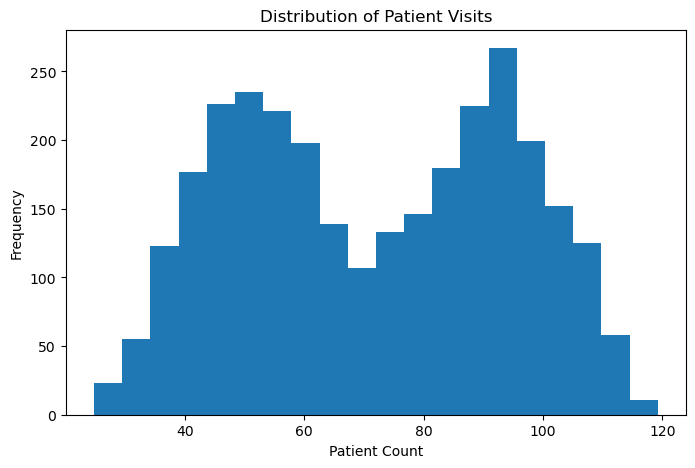

In [8]:
plt.figure(figsize=(8,5))
plt.hist(df["patients"], bins=20)
plt.xlabel("Patient Count")
plt.ylabel("Frequency")
plt.title("Distribution of Patient Visits")
plt.show()

### 4.2 Rainfall vs Patients

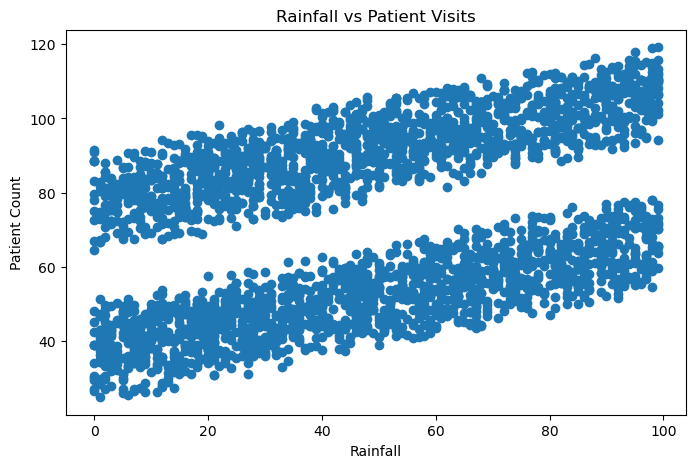

In [9]:
plt.figure(figsize=(8,5))
plt.scatter(df["rainfall"], df["patients"])
plt.xlabel("Rainfall")
plt.ylabel("Patient Count")
plt.title("Rainfall vs Patient Visits")
plt.show()

### 4.3 Exam period vs Patients

C:\Users\Administrator\AppData\Local\Temp\ipykernel_30232\751514038.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


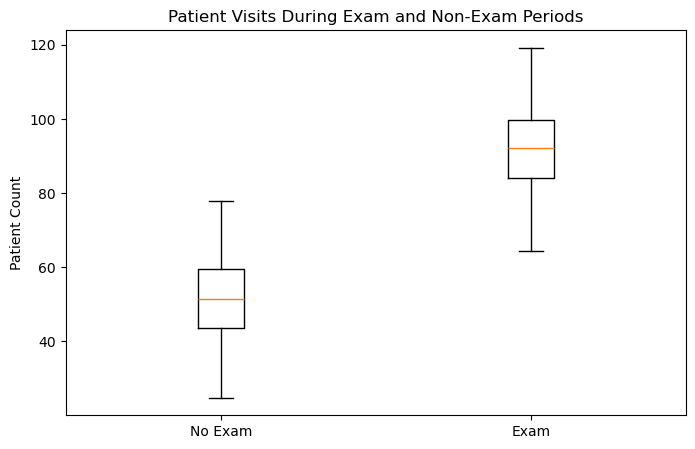

In [10]:
plt.figure(figsize=(8,5))
plt.boxplot(
    [
        df[df["exam_period"] == 0]["patients"],
        df[df["exam_period"] == 1]["patients"]
    ],
    labels=["No Exam", "Exam"]
)

plt.ylabel("Patient Count")
plt.title("Patient Visits During Exam and Non-Exam Periods")
plt.show()

## 5. Feature Selection

The selected input features are:
- Exam Period
- Rainfall
- Temperature

The target variable is:
- Patient Count

In [11]:
# Input features
X = df[["exam_period", "rainfall", "temperature"]]

# Target variable
y = df["patients"]

### 5.1 Train-Test Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### 5.2 Model Training

The project uses Linear Regression to predict patient visits based on academic and environmental factors.

In [13]:
# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### 5.3 Model Coefficients

In [14]:
# Display coefficients
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients

,Feature,Coefficient
0,exam_period,40.330272
1,rainfall,0.296404
2,temperature,-0.519459


### 5.4 Making Predictions

The trained model is used to predict patient counts using unseen test data.

In [15]:
# Predict values
y_pred = model.predict(X_test)

## 6. Model Evaluation

The model is evaluated using:
- RMSE (Root Mean Squared Error)
- R² Score

In [16]:
# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Calculate R² score
r2 = r2_score(y_test, y_pred)

# Display results
print("RMSE:", rmse)
print("R² Score:", r2)

RMSE: 5.63136030719483
R² Score: 0.9381770866440549


## 7. Actual vs Predicted Graph

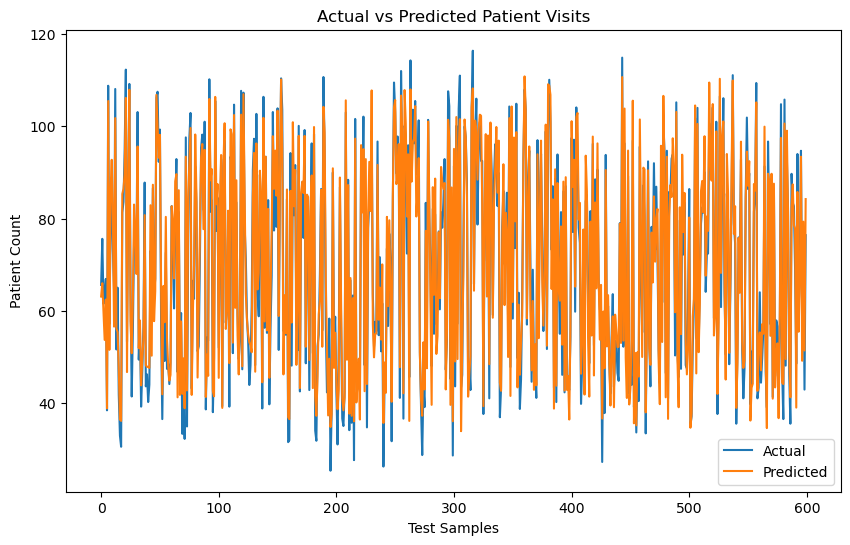

In [17]:
plt.figure(figsize=(10,6))

plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")

plt.xlabel("Test Samples")
plt.ylabel("Patient Count")
plt.title("Actual vs Predicted Patient Visits")

plt.legend()

plt.show()

## 8. Interpretation of Results

The model achieved a high R² score and a relatively low RMSE, indicating strong predictive performance.

The results show that:
- Examination periods strongly increase clinic visits
- Rainfall moderately affects patient demand
- Temperature has a smaller negative effect

The findings align with survey responses collected from students, validating the effectiveness of the predictive model.

## 9. Conclusion

This project successfully developed a machine learning model capable of predicting student clinic visits using examination periods and weather conditions.

The system demonstrates the potential of predictive analytics in improving healthcare planning, reducing waiting times, and supporting proactive resource allocation in university clinics.